# Аппроксимация ядер против градиентного бустинга

Ядровой SVM даёт сильное качество, но плохо масштабируется: нужно хранить матрицу Грама и решать задачу условной оптимизации. Random Fourier Features предлагают обходной путь — нагенерировать случайные нелинейные признаки так, чтобы скалярное произведение в новом пространстве приближало гауссово ядро, и обучить поверх них обычную линейную модель. Получается нелинейная модель за линейное время.

Проверяю, насколько эта идея работоспособна на практике. Признаки строятся как $\tilde \varphi(x) = (\cos(w_1^T x + b_1), \dots, \cos(w_n^T x + b_n))$, где $w_j \sim \mathcal{N}(0, 1/\sigma^2)$, а $\sigma^2$ оценивается медианной эвристикой по случайному подмножеству пар. Данные — Fashion MNIST.

Сравнение идёт по двум осям сразу, качеству и скорости: RFF с логистической регрессией и с линейным SVM против точного ядрового SVM, обычного линейного SVM и градиентного бустинга. Дополнительно реализованы два развития метода — Orthogonal Random Features, где случайные направления ортогонализуются, и FastFood со структурированной факторизацией матрицы весов через преобразование Уолша–Адамара. В последнем разделе тот же приём переносится на регрессию, где RFF сравнивается с ядровой Ridge-регрессией (аналитическое решение и градиентный спуск с выведенным градиентом).

Стек: NumPy, scikit-learn, LightGBM/CatBoost/XGBoost.

---


### О проекте

Метод опорных векторов (SVM) в базовой версии использует специальную функцию потерь, которая не требует устремлять отступы к бесконечности; ей достаточно, чтобы отступы были не меньше +1. SVM можно переписать в двойственном виде, который позволяет заменить скалярные произведения объектов на ядра — это соответствует построению модели в новом пространстве более высокой размерности, координаты которого являются нелинейными модификациями исходных признаков.

Ядровой SVM, к сожалению, довольно затратен по памяти (нужно хранить матрицу Грама размера $d \times d$) и по времени (нужно решать задачу условной оптимизации с квадратичной функцией, а это не очень быстро). Существуют способы посчитать новые признаки $\tilde \varphi(x)$ на основе исходных так, что скалярные произведения этих новых $\langle \tilde \varphi(x), \tilde \varphi(z) \rangle$ приближают ядро $K(x, z)$.

В проекте исследуются аппроксимации методом Random Fourier Features (RFF, также в литературе встречается название Random Kitchen Sinks) для гауссовых ядер, по формулам со сдвигами внутри тригонометрических функций (используются только косинусы, потому что с нужным сдвигом косинус превращается в синус):
$$\tilde \varphi(x) = (
\cos (w_1^T x + b_1),
\dots,
\cos (w_n^T x + b_n)
),$$
где $w_j \sim \mathcal{N}(0, 1/\sigma^2)$, $b_j \sim U[-\pi, \pi]$.

На новых признаках $\tilde \varphi(x)$ строится любая линейная модель.

Это можно рассматривать как альтернативную парадигму построения сложных моделей: вместо направленного поиска нелинейных закономерностей (градиентный бустинг, нейросети) — генерация большого количества случайных нелинейных признаков в расчёте на то, что быстрая и простая линейная модель на них покажет хорошее качество. Проект проверяет, насколько такая идея работоспособна на практике.

### Алгоритм

1. Понизить размерность выборки до new_dim с помощью метода главных компонент.
2. Для полученной выборки оценить гиперпараметр $\sigma^2$ с помощью эвристики (медиана по случайному подмножеству из порядка миллиона пар объектов, а не по всем парам): $$\sigma^2 = \text{median}_{i, j = 1, \dots, \ell, i \neq j} \left\{\sum_{k = 1}^{d} (x_{ik} - x_{jk})^2 \right\}$$
3. Сгенерировать n_features наборов весов $w_j$ и сдвигов $b_j$.
4. Сформировать n_features новых признаков по формулам, приведённым выше.
5. Обучить линейную модель (логистическую регрессию или SVM) на новых признаках.
6. Повторить преобразования (PCA, формирование новых признаков) к тестовой выборке и применить модель.

In [35]:
%load_ext autoreload
%autoreload 2

Тестировать алгоритм мы будем на данных Fashion MNIST. Ниже код для их загрузки и подготовки.

In [38]:
import numpy as np

# 1 Способ 
import keras
from keras.datasets import fashion_mnist
(x_train_pics, y_train), (x_test_pics, y_test) = fashion_mnist.load_data()

# 2 Способ (если первый не работает)
# from sklearn.datasets import fetch_openml
# def load_fashion_mnist():
#     X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
#     X = X.reshape(-1, 28, 28).astype('uint8')
#     y = y.astype('int64')
#     x_train, x_test = X[:60000], X[60000:]
#     y_train, y_test = y[:60000], y[60000:]
#     return (x_train, y_train), (x_test, y_test)
# (x_train_pics, y_train), (x_test_pics, y_test) = load_fashion_mnist()




x_train = x_train_pics.reshape(y_train.shape[0], -1)
x_test = x_test_pics.reshape(y_test.shape[0], -1)

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

x_train = x_train.astype(np.float64) / 255.0
x_test  = x_test.astype(np.float64) / 255.0

print(f'x_train: {x_train.shape}, y_train: {y_train.shape}')
print(f'x_test : {x_test.shape}, y_test : {y_test.shape}')
print(f'unique labels: {np.unique(y_train)}')

x_train: (60000, 784), y_train: (60000,)
x_test : (10000, 784), y_test : (10000,)
unique labels: [0 1 2 3 4 5 6 7 8 9]



**Вопрос:** зачем в алгоритме нужен метод главных компонент? 

**Ответ:** Поскольку попарные расстояния почти одинаковы в исходном пространстве, значения гауссова ядра для разных пар объектов тоже приближены друг к другу, следовательно, матрица Грама оказывается плохо обусловленной. После снижения размерности оценка дисперсии оказывается менее замшумленной, модель аппроксимирует лучше. Более того, матрица весов становится легче (ее проще хранить в памяти) и фичи генерируются быстрее. 

Реализуем описанный выше алгоритм. Реализация поддерживает:

1. Задание гиперпараметров `new_dim` (по умолчанию 50) и `n_features` (по умолчанию 1000).
2. Включение и отключение предварительного понижения размерности через PCA.
3. Выбор типа линейной модели — логистическая регрессия или SVM с линейным ядром.

Проверяю на Fashion MNIST, подготовленном кодом выше. Ориентир корректности — доля верных ответов на тесте не ниже 0.84 с гиперпараметрами по умолчанию.

In [42]:
from homework_practice_11_rff import RFFPipeline, RandomFeatureCreator

pipeline = RFFPipeline(
    n_features=1000,
    new_dim=50,
    feature_creator_class=RandomFeatureCreator,
    classifier_class=__import__('sklearn.linear_model', fromlist=['LogisticRegression']).LogisticRegression,
    classifier_params={'max_iter': 1000, 'C': 1.0, 'n_jobs': -1},
)

t0 = time.time()
pipeline.fit(x_train, y_train)
t_fit = time.time() - t0

t0 = time.time()
acc_train = pipeline.score(x_train, y_train)
acc_test  = pipeline.score(x_test, y_test)
t_pred = time.time() - t0

print(f'Train accuracy: {acc_train:.4f}')
print(f'Test  accuracy: {acc_test:.4f}')
print(f'Fit  time: {t_fit:.1f}s')
print(f'Pred time (train+test): {t_pred:.1f}s')

sigma2 = pipeline.pipeline.named_steps['rff'].sigma2_
print(f'Estimated sigma^2 (after PCA): {sigma2:.4f}')

Train accuracy: 0.8547
Test  accuracy: 0.8396
Fit  time: 18.0s
Pred time (train+test): 1.7s
Estimated sigma^2 (after PCA): 112.3196


Сравним подход со случайными признаками с обучением SVM на исходных признаках — в двух вариантах, с линейным и с ядровым SVM. Ядровой SVM обучается долго, поэтому для ускорения беру подмножество объектов обучающей выборки.

Второе сравнение — против связки «PCA + градиентный бустинг» на одной из реализаций CatBoost/LightGBM/XGBoost.

Смотрю на обе стороны: и на качество, и на скорость обучения и применения.

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

def evaluate(model, x_tr, y_tr, x_te, y_te, name=''):
    t0 = time.time(); model.fit(x_tr, y_tr); t_fit = time.time() - t0
    t0 = time.time(); pred = model.predict(x_te); t_pred = time.time() - t0
    acc = (pred == y_te).mean()
    print(f'{name:35s} acc={acc:.4f}  fit={t_fit:6.1f}s  pred={t_pred:5.1f}s')
    return {'name': name, 'acc': acc, 'fit_time': t_fit, 'pred_time': t_pred}


results = []

In [45]:
rff_model = RFFPipeline(
    n_features=1000, new_dim=50,
    feature_creator_class=RandomFeatureCreator,
    classifier_class=LogisticRegression,
    classifier_params={'max_iter': 1000, 'C': 1.0, 'n_jobs': -1},
)
results.append(evaluate(rff_model, x_train, y_train, x_test, y_test, 'RFF + Logistic Regression'))

RFF + Logistic Regression           acc=0.8396  fit=  18.2s  pred=  0.2s


In [46]:
linsvm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(C=1.0, max_iter=2000, dual='auto')),
])
results.append(evaluate(linsvm, x_train, y_train, x_test, y_test, 'Linear SVM (raw 784-d)'))

Linear SVM (raw 784-d)              acc=0.8372  fit=1553.0s  pred=  0.8s


In [47]:
from sklearn.model_selection import train_test_split

sub_idx_full = np.arange(len(x_train))
_, sub_idx = train_test_split(sub_idx_full, train_size=min(10000, len(x_train) // 2), stratify=y_train, random_state=42)
x_sub, y_sub = x_train[sub_idx], y_train[sub_idx]

kernsvm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=50, random_state=42)),
    ('svm', SVC(C=1.0, kernel='rbf', gamma='scale')),
])
results.append(evaluate(kernsvm, x_sub, y_sub, x_test, y_test, 'Kernel SVM (RBF, 10k subsample)'))

Kernel SVM (RBF, 10k subsample)     acc=0.8650  fit=  22.9s  pred= 14.7s


In [48]:
gbm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=50, random_state=42)),
    ('gbm', lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                                num_leaves=63, n_jobs=-1, verbose=-1, random_state=42)),
])
results.append(evaluate(gbm_pipeline, x_train, y_train, x_test, y_test, 'LightGBM (PCA-50)'))

LightGBM (PCA-50)                   acc=0.8742  fit=  21.4s  pred=  0.4s


In [50]:
import pandas as pd
summary = pd.DataFrame(results)
print(summary.to_string(index=False, formatters={'acc': '{:.4f}'.format,
                                                 'fit_time': '{:.1f}s'.format,
                                                 'pred_time': '{:.1f}s'.format}))

                           name    acc fit_time pred_time
      RFF + Logistic Regression 0.8396    18.2s      0.2s
         Linear SVM (raw 784-d) 0.8372  1553.0s      0.8s
Kernel SVM (RBF, 10k subsample) 0.8650    22.9s     14.7s
              LightGBM (PCA-50) 0.8742    21.4s      0.4s


> Деревья в бустинге хорошо улавлиают нелинейные зависимости на фэшн мнисте. LightGBM показывает лучшее качество.

> >  Ядровой svm на подвыборке по качеству уступает только бустингу. Но метод медленнее rff и не настолько масштабируем с т.з. выборки.

> > > Идея со случанйыми признаками работает. RFF+LogReg обучается быстрее всех (не строим матрицу Грама напрямую, а аппроксимируем ядровой svm). По качеству не хуже линейного svm, но хуже бустинга и svm с точным ядром на подвыборке (нелинейные зависимости есть, но не в полной мере улавливаются моделью). Таким образом, за линейное время получаем нелинейную модель.         


Проведите эксперименты:
1. Помогает ли предварительное понижение размерности с помощью PCA? 
2. Как зависит итоговое качество от n_features? Выходит ли оно на плато при росте n_features?
3. Важно ли, какую модель обучать — логистическую регрессию или SVM?

In [54]:
print('PCA on/off comparison')
for use_pca in [True, False]:
    pipe = RFFPipeline(
        n_features=1000, new_dim=50,
        use_PCA=use_pca,
        feature_creator_class=RandomFeatureCreator,
        classifier_class=LogisticRegression,
        classifier_params={'max_iter': 1000, 'C': 1.0, 'n_jobs': -1},
    )
    t0 = time.time(); pipe.fit(x_train, y_train); t_fit = time.time() - t0
    acc = pipe.score(x_test, y_test)
    label = f'use_PCA={use_pca}'
    print(f'{label:15s}  acc={acc:.4f}  fit={t_fit:.1f}s')

PCA on/off comparison
use_PCA=True     acc=0.8396  fit=16.8s
use_PCA=False    acc=0.8469  fit=19.7s


> PCA хорошо помогает для ускорения обучения, но слегка может портить качество на наших данных. Может быть, при большей размерности или зашумленности   данных accuracy после pca был бы выше.

In [70]:
n_features_list = [50, 100, 200, 500, 1000, 2000, 5000]
acc_logreg = []
acc_svm = []
fit_times = []

for nf in n_features_list:
    print(f'-> n_features={nf}')
    pipe = RFFPipeline(
        n_features=nf, new_dim=50,
        feature_creator_class=RandomFeatureCreator,
        classifier_class=LogisticRegression,
        classifier_params={'max_iter': 1000, 'C': 1.0, 'n_jobs': -1},
    )
    t0 = time.time(); pipe.fit(x_train, y_train); fit_times.append(time.time() - t0)
    acc_logreg.append(pipe.score(x_test, y_test))

    pipe_svm = RFFPipeline(
        n_features=nf, new_dim=50,
        feature_creator_class=RandomFeatureCreator,
        classifier_class=LinearSVC,
        classifier_params={'C': 1.0, 'max_iter': 2000, 'dual': 'auto'},
    )
    pipe_svm.fit(x_train, y_train)
    acc_svm.append(pipe_svm.score(x_test, y_test))
    print(f'   logreg acc={acc_logreg[-1]:.4f}  svm acc={acc_svm[-1]:.4f}')

-> n_features=50
   logreg acc=0.8103  svm acc=0.8087
-> n_features=100
   logreg acc=0.8259  svm acc=0.8296
-> n_features=200
   logreg acc=0.8297  svm acc=0.8465
-> n_features=500
   logreg acc=0.8389  svm acc=0.8578
-> n_features=1000
   logreg acc=0.8396  svm acc=0.8607
-> n_features=2000
   logreg acc=0.8408  svm acc=0.8613
-> n_features=5000
   logreg acc=0.8422  svm acc=0.8631


> При росте n_features качество монтонно растет, выходя на плато примерно с 1000, ведь дисперсия аппроксимации ядра убывает как O(1/n).

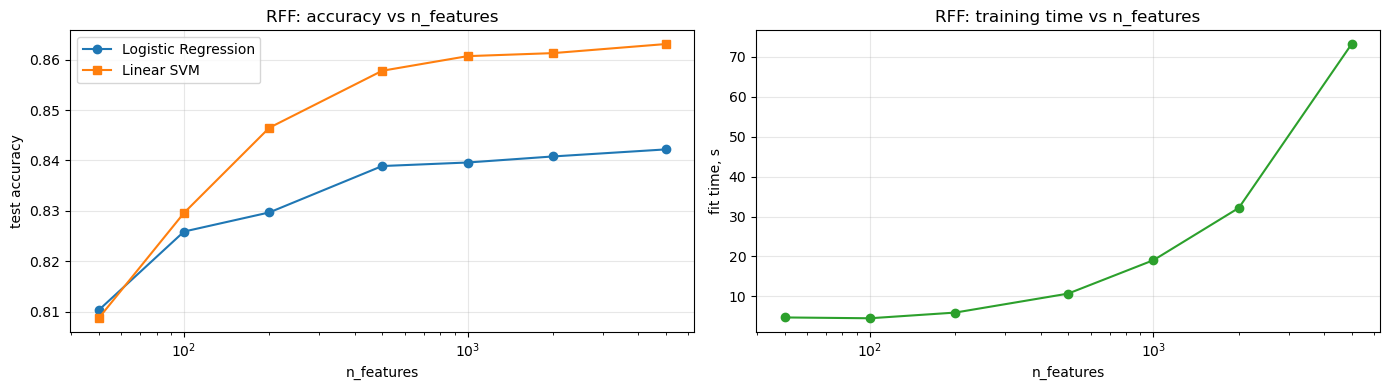

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(n_features_list, acc_logreg, 'o-', label='Logistic Regression')
ax.plot(n_features_list, acc_svm, 's-', label='Linear SVM')
ax.set_xscale('log')
ax.set_xlabel('n_features')
ax.set_ylabel('test accuracy')
ax.set_title('RFF: accuracy vs n_features')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(n_features_list, fit_times, 'o-', color='C2')
ax.set_xscale('log')
ax.set_xlabel('n_features')
ax.set_ylabel('fit time, s')
ax.set_title('RFF: training time vs n_features')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> Линейный svm лучше логистической регрессии, особенно выраженным разрыв становится после выхода на плато (n_features = 1000), когда ядро уже хорошо аппроксимировано.

* HingeLoss у SVM штрафует объекты вблизи разделяющей гиперплоскости сильнее, чем LogLoss у логрега, поэтому в пространстве RFF-признаков классы разделяются лучше

__Ортогональные случайные признаки (ORF).__ Многие алгоритмы машинного обучения работают лучше, если признаки данных некоррелированы. Для RFF существует модификация, позволяющая получать ортогональные случайные признаки (Orthogonal Random Features, ORF). Об этом методе можно прочитать в [статье](https://proceedings.neurips.cc/paper/2016/file/53adaf494dc89ef7196d73636eb2451b-Paper.pdf). Реализован класс для вычисления ORF по аналогии с основным алгоритмом, поддерживающий случаи n_features > new_dim, n_features = new_dim и n_features < new_dim. Ниже — эксперименты, сравнивающие RFF и ORF.

In [75]:
from homework_practice_11_rff import OrthogonalRandomFeatureCreator

n_features_list_orf = [50, 100, 200, 500, 1000, 2000]
n_seeds = 3

rff_means, rff_stds = [], []
orf_means, orf_stds = [], []

for nf in n_features_list_orf:
    rff_runs = []
    orf_runs = []
    for seed in range(n_seeds):
        for fc_cls, runs in [(RandomFeatureCreator, rff_runs),
                              (OrthogonalRandomFeatureCreator, orf_runs)]:
            class FC(fc_cls):
                def __init__(self, n_features, new_dim, func):
                    super().__init__(n_features=n_features, new_dim=new_dim,
                                      func=func, random_state=seed)
            pipe = RFFPipeline(
                n_features=nf, new_dim=50,
                feature_creator_class=FC,
                classifier_class=LogisticRegression,
                classifier_params={'max_iter': 1000, 'C': 1.0, 'n_jobs': -1},
            )
            pipe.fit(x_train, y_train)
            runs.append(pipe.score(x_test, y_test))
    rff_means.append(np.mean(rff_runs))
    rff_stds.append(np.std(rff_runs))
    orf_means.append(np.mean(orf_runs))
    orf_stds.append(np.std(orf_runs))
    print(f'n={nf:5d}: RFF={rff_means[-1]:.4f} +- {rff_stds[-1]:.4f}, '
          f'ORF={orf_means[-1]:.4f} +- {orf_stds[-1]:.4f}')

n=   50: RFF=0.8007 +- 0.0030, ORF=0.8085 +- 0.0039
n=  100: RFF=0.8253 +- 0.0036, ORF=0.8267 +- 0.0007
n=  200: RFF=0.8327 +- 0.0023, ORF=0.8329 +- 0.0013
n=  500: RFF=0.8377 +- 0.0004, ORF=0.8383 +- 0.0008
n= 1000: RFF=0.8394 +- 0.0010, ORF=0.8399 +- 0.0005
n= 2000: RFF=0.8415 +- 0.0001, ORF=0.8415 +- 0.0008


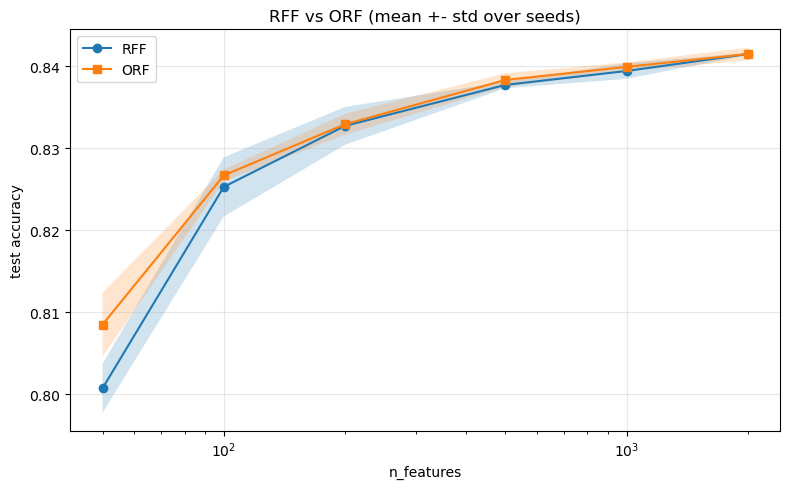

In [76]:
fig, ax = plt.subplots(figsize=(8, 5))
rff_means = np.array(rff_means); rff_stds = np.array(rff_stds)
orf_means = np.array(orf_means); orf_stds = np.array(orf_stds)
ax.plot(n_features_list_orf, rff_means, 'o-', label='RFF')
ax.fill_between(n_features_list_orf, rff_means - rff_stds, rff_means + rff_stds, alpha=0.2)
ax.plot(n_features_list_orf, orf_means, 's-', label='ORF')
ax.fill_between(n_features_list_orf, orf_means - orf_stds, orf_means + orf_stds, alpha=0.2)
ax.set_xscale('log')
ax.set_xlabel('n_features')
ax.set_ylabel('test accuracy')
ax.set_title('RFF vs ORF (mean +- std over seeds)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

> ORF стабильно не хуже RFF, среднее качество чуть выше при малых n_features. А с ростом числа признаков методы сходятся.

> ORF хорош меньшей дисперсией. Ортогональные направления равномернее покрывают пространство, поэтому результат меньше зависит от рандомного сида. В общем и целом ортогонализация уменьшает дисперсию аппроксимации ядра, не меняя мат. ожидание.

Идея RFF развивается во многих работах, где предлагаются её обобщения — по сути другие преобразования признаков, не обязательно тригонометрические. Возьму одну из таких работ, разберу идею, реализую и сравню качество с RFF и ORF выше. Обзор вариаций RFF для разных ядер есть в окрестности таблицы 1 работы https://arxiv.org/pdf/1407.5599.

Выбранная работа: [FastFood](https://arxiv.org/pdf/1408.3060).

Идея метода: в Fastfood матрица $W \in \mathbb{R}^{d \times n}$ для RFF заменяется структурированным произведением вида

$$
W = \frac{1}{\sigma \sqrt{d}} S H G \Pi H B,
$$

где:
- $B$ — диагональная матрица случайных знаков $\pm 1$,
- $H$ — *матрица Уолша–Адамара* (умножение на неё реализуется за $O(d \log d)$ через быстрое преобразование Адамара),
- $\Pi$ — случайная матрица перестановки,
- $G$ — диагональная матрица c i.i.d. $\mathcal{N}(0, 1)$ на диагонали,
- $S$ — диагональная матрица, перенормирующая строчные нормы к распределению $\chi_d$.

В итоге умножение $W^T x$ требует $O(n \log d)$ операций вместо $O(n d)$, а память — $O(n)$ вместо $O(nd)$, что особенно выгодно при больших $d$ и $n$.

In [79]:
from sklearn.base import BaseEstimator, TransformerMixin

def _fwht(a: np.ndarray) -> np.ndarray:
    a = a.copy()
    n, d = a.shape
    h = 1
    while h < d:
        for i in range(0, d, h * 2):
            x = a[:, i:i + h].copy()
            y = a[:, i + h:i + 2 * h].copy()
            a[:, i:i + h] = x + y
            a[:, i + h:i + 2 * h] = x - y
        h *= 2
    return a


class FastfoodFeatureCreator(BaseEstimator, TransformerMixin):
    def __init__(self, n_features=1000, new_dim=50, func=np.cos,
                 random_state=42, n_pairs_for_sigma=1_000_000):
        self.n_features = n_features
        self.new_dim = new_dim
        self.func = func
        self.random_state = random_state
        self.n_pairs_for_sigma = n_pairs_for_sigma

    def _estimate_sigma2(self, X, rng):
        n = X.shape[0]
        n_pairs = int(min(self.n_pairs_for_sigma, n * (n - 1) // 2))
        i = rng.integers(0, n, n_pairs); j = rng.integers(0, n, n_pairs)
        same = i == j
        while np.any(same):
            j[same] = rng.integers(0, n, int(same.sum()))
            same = i == j
        chunk = 100_000
        sq = np.empty(n_pairs)
        for s in range(0, n_pairs, chunk):
            e = min(s + chunk, n_pairs)
            d_ = X[i[s:e]] - X[j[s:e]]
            sq[s:e] = np.einsum('ij,ij->i', d_, d_)
        return float(np.median(sq)) or 1.0

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=np.float64)
        rng = np.random.default_rng(self.random_state)
        self.sigma2_ = self._estimate_sigma2(X, rng)
        d = X.shape[1]
        d_pad = 1
        while d_pad < d:
            d_pad *= 2
        self.d_pad_ = d_pad
        n_blocks = int(np.ceil(self.n_features / d_pad))
        self.n_blocks_ = n_blocks

        self.B_ = rng.choice([-1.0, 1.0], size=(n_blocks, d_pad))
        self.Pi_ = np.stack([rng.permutation(d_pad) for _ in range(n_blocks)])

        self.G_ = rng.normal(size=(n_blocks, d_pad))
        chi = np.sqrt(rng.chisquare(df=d_pad, size=(n_blocks, d_pad)))
        g_norms = np.linalg.norm(self.G_, axis=1, keepdims=True)
        self.S_ = chi / g_norms
        self.b_ = rng.uniform(-np.pi, np.pi, size=self.n_features)
        return self

    def transform(self, X, y=None):
        X = np.asarray(X, dtype=np.float64)
        n, d = X.shape
        if d < self.d_pad_:
            X = np.concatenate([X, np.zeros((n, self.d_pad_ - d))], axis=1)
        outputs = []
        for k in range(self.n_blocks_):
            z = X * self.B_[k]            
            z = _fwht(z)                 
            z = z[:, self.Pi_[k]]       
            z = z * self.G_[k]            
            z = _fwht(z)                  
            z = z * self.S_[k]           
            outputs.append(z)
        Z = np.concatenate(outputs, axis=1)[:, :self.n_features]
        Z = Z / (np.sqrt(self.sigma2_) * np.sqrt(self.d_pad_))
        return self.func(Z + self.b_) * np.sqrt(2.0 / self.n_features)

In [80]:
def run_pipeline(fc_class, nf=1000, **kw):
    pipe = RFFPipeline(
        n_features=nf, new_dim=64,  
        feature_creator_class=fc_class,
        classifier_class=LogisticRegression,
        classifier_params={'max_iter': 1000, 'C': 1.0, 'n_jobs': -1},
        **kw,
    )
    t0 = time.time(); pipe.fit(x_train, y_train); t_fit = time.time() - t0
    acc = pipe.score(x_test, y_test)
    return acc, t_fit


for n_feat in [500, 1000, 2000]:
    print(f'n_features={n_feat}')
    acc_rff, t_rff = run_pipeline(RandomFeatureCreator, nf=n_feat)
    print(f'RFF acc={acc_rff:.4f}  fit={t_rff:.1f}s')
    acc_orf, t_orf = run_pipeline(OrthogonalRandomFeatureCreator, nf=n_feat)  
    print(f'ORF acc={acc_orf:.4f}  fit={t_orf:.1f}s')
    acc_ff,  t_ff  = run_pipeline(FastfoodFeatureCreator, nf=n_feat)
    print(f'Fastfood acc={acc_ff:.4f}  fit={t_ff:.1f}s')

n_features=500
RFF acc=0.8423  fit=10.0s
ORF acc=0.8410  fit=7.6s
Fastfood acc=0.8405  fit=13.1s
n_features=1000
RFF acc=0.8427  fit=15.7s
ORF acc=0.8423  fit=15.4s
Fastfood acc=0.8420  fit=23.7s
n_features=2000
RFF acc=0.8422  fit=31.8s
ORF acc=0.8454  fit=31.1s
Fastfood acc=0.8429  fit=41.7s


>  Так как классификатор работает на плато, и для линейного разделения классов хватает приближенной аппроксимации ядра, то все три метода: RFF, ORF, Fastfood дают практически одинаковую accuracy классификации на Fashion MNIST. По скорости Fastfood с FWHT имеет асимптотику O(nlog d) против O(nd), но на сжатом PCA-пространстве эффект незаметен.

Median heuristic sigma: 33.4220
True kernel shape: (1000, 1000), mean=0.5874

Mean absolute error of kernel approximation:
              RFF    ORF  Fastfood
n_features                        
100        0.0681 0.0500    0.0706
500        0.0290 0.0197    0.0299
2000       0.0173 0.0106    0.0124
5000       0.0096 0.0076    0.0096


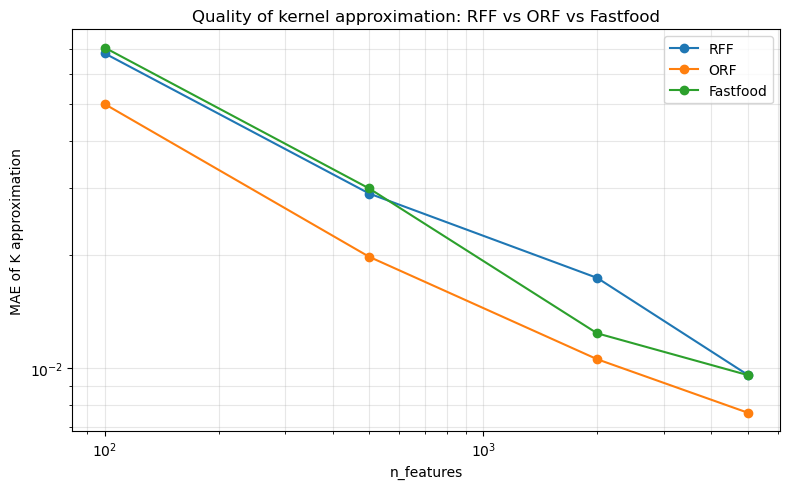

In [81]:
from sklearn.gaussian_process.kernels import RBF
from sklearn.decomposition import PCA as SKPCA

X_quality = SKPCA(n_components=64, random_state=42).fit_transform(
    StandardScaler().fit_transform(x_train[:1000]))
sigma = np.sqrt(np.median(
    [((X_quality[i] - X_quality[j])**2).sum()
     for i in range(100) for j in range(100) if i != j]))
print(f'Median heuristic sigma: {sigma:.4f}')
K_true = RBF(sigma)(X_quality)
print(f'True kernel shape: {K_true.shape}, mean={K_true.mean():.4f}')

rff_mae = {}
orf_mae = {}
ff_mae = {}
for n_feat in [100, 500, 2000, 5000]:

    fc = RandomFeatureCreator(n_features=n_feat, new_dim=64, random_state=42)
    fc.fit(X_quality); fc.sigma2_ = sigma**2
    rng = np.random.default_rng(42)
    fc.w = rng.normal(0, 1/sigma, size=(64, n_feat))
    fc.b = rng.uniform(-np.pi, np.pi, size=n_feat)
    Phi = fc.transform(X_quality)
    K_rff = Phi @ Phi.T
    rff_mae[n_feat] = np.abs(K_rff - K_true).mean()
    

    fc = OrthogonalRandomFeatureCreator(n_features=n_feat, new_dim=64, random_state=42)
    fc.fit(X_quality); fc.sigma2_ = sigma**2
    rng = np.random.default_rng(42)
    n_blocks = int(np.ceil(n_feat / 64))
    cols = []
    for _ in range(n_blocks):
        G = rng.normal(size=(64, 64))
        Q, _ = np.linalg.qr(G)
        s = np.sqrt(rng.chisquare(df=64, size=64))
        cols.append(Q * s[None, :])
    fc.w = np.concatenate(cols, axis=1)[:, :n_feat] / sigma
    fc.b = rng.uniform(-np.pi, np.pi, size=n_feat)
    Phi = fc.transform(X_quality)
    K_orf = Phi @ Phi.T
    orf_mae[n_feat] = np.abs(K_orf - K_true).mean()

    
    fc = FastfoodFeatureCreator(n_features=n_feat, random_state=42)
    fc.fit(X_quality); fc.sigma2_ = sigma**2
    Phi = fc.transform(X_quality)
    K_ff = Phi @ Phi.T
    ff_mae[n_feat] = np.abs(K_ff - K_true).mean()

df_mae = pd.DataFrame({'RFF': rff_mae, 'ORF': orf_mae, 'Fastfood': ff_mae})
df_mae.index.name = 'n_features'
print('\nMean absolute error of kernel approximation:')
print(df_mae.to_string(float_format='{:.4f}'.format))


fig, ax = plt.subplots(figsize=(8, 5))
for col in df_mae.columns:
    ax.plot(df_mae.index, df_mae[col], 'o-', label=col)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('n_features')
ax.set_ylabel('MAE of K approximation')
ax.set_title('Quality of kernel approximation: RFF vs ORF vs Fastfood')
ax.grid(True, alpha=0.3, which='both')
ax.legend()
plt.tight_layout(); plt.show()

> По точности аппроксимации ядра ORF все еще лучший, но Fastfood слегка выигрывает у RFF при относительно больших n

__Ядровая Ridge-регрессия.__ Реализован класс ядровой Ridge-регрессии: оптимизация как через градиентный спуск (с выводом градиента), так и через аналитическую формулу. Также учтено, как правильно включить в формулы свободный коэффициент.

Затем реализация RFF адаптирована под задачу регрессии, и ядровая регрессия сравнивается с RFF на синтетических данных.

Функция потерь:
$$Q(w) = \frac{1}{2}\|Kw - y\|^2 + \frac{\lambda}{2}\, w^T K w \;\to\; \min_w,$$

где $K = \big(k(x_i, x_j)\big)_{i,j=1}^{\ell}$ - матрица Грама, $w \in \mathbb{R}^{\ell}$ - вектор дуальных весов.

Предсказание:
$$\hat{y}(x) = k(x)^T w, \qquad k(x) = \big(k(x, x_1), \ldots, k(x, x_\ell)\big)^T.$$

**Вывод градиента.** Раскроем квадрат нормы:
$$Q(w) = \frac{1}{2}(Kw - y)^T(Kw - y) + \frac{\lambda}{2}\, w^T K w.$$

Дифференцируем по $w$, пользуясь симметричностью $K = K^T$:
$$\frac{\partial}{\partial w}\left[\frac{1}{2}\|Kw - y\|^2\right] = K^T(Kw - y) = K(Kw - y),$$
$$\frac{\partial}{\partial w}\left[\frac{\lambda}{2}\, w^T K w\right] = \lambda K w.$$


$${\;\nabla Q(w) = K(Kw - y) + \lambda K w = K\big((K + \lambda I)\,w - y\big).\;}$$

**Аналитическое решение.** 
$$(K + \lambda I)\,w = y \quad\Longrightarrow\quad w^* = (K + \lambda I)^{-1} y.$$

Матрица $K + \lambda I$ положительно определена при $\lambda > 0$.

**Учёт свободного коэффициента.** Свободный член учитывается через центрирование таргета: вычисляем $\bar{y} = \frac{1}{\ell}\sum_i y_i$, обучаем $w$ на центрированных значениях $\tilde{y} = y - \bar{y}$, а при предсказании прибавляем $\bar{y}$ обратно:
$$\hat{y}(x) = k(x)^T w + \bar{y}.$$

Train: (300, 2), Test: (200, 2)
Closed-form: MSE=0.0186  R2=0.9753
GD: MSE=0.0199  R2=0.9736  (final loss=2.9010)


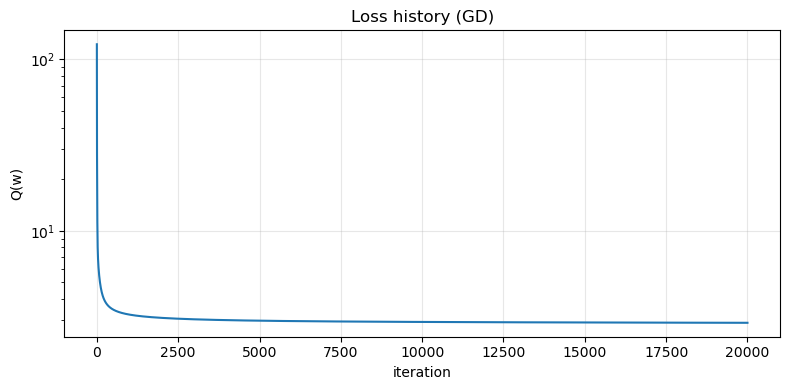

In [123]:
from homework_practice_11_kernel_regression import KernelRidgeRegression
from sklearn.metrics import mean_squared_error, r2_score

rng = np.random.default_rng(0)
n_train, n_test = 300, 200
X_full = rng.uniform(-3, 3, size=(n_train + n_test, 2))

def target(X):
    return np.sin(2 * X[:, 0]) * np.cos(X[:, 1]) + 0.3 * X[:, 0] - 0.2 * X[:, 1]**2

y_full = target(X_full) + 0.1 * rng.normal(size=len(X_full))
X_tr, X_te = X_full[:n_train], X_full[n_train:]
y_tr, y_te = y_full[:n_train], y_full[n_train:]
print(f'Train: {X_tr.shape}, Test: {X_te.shape}')

model_cf = KernelRidgeRegression(regularization=0.1, kernel_scale=0.7)
model_cf.fit_closed_form(X_tr, y_tr)
pred_cf = model_cf.predict(X_te)
mse_cf = mean_squared_error(y_te, pred_cf)
r2_cf = r2_score(y_te, pred_cf)
print(f'Closed-form: MSE={mse_cf:.4f}  R2={r2_cf:.4f}')

model_gd = KernelRidgeRegression(
    lr=2e-3, regularization=0.1, kernel_scale=0.7,
    max_iter=20000, batch_size=300, tolerance=1e-10,
)
model_gd.fit(X_tr, y_tr)
pred_gd = model_gd.predict(X_te)
mse_gd = mean_squared_error(y_te, pred_gd)
r2_gd = r2_score(y_te, pred_gd)
print(f'GD: MSE={mse_gd:.4f}  R2={r2_gd:.4f}  (final loss={model_gd.loss_history[-1]:.4f})')

plt.figure(figsize=(8, 4))
plt.plot(model_gd.loss_history)
plt.xlabel('iteration'); plt.ylabel('Q(w)')
plt.yscale('log')
plt.title('Loss history (GD)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

> Аналитическое решение даёт MSE=0.0186, R²=0.9753. Градиентный спуск чуть хуже - MSE=0.0199, R²=0.9736. GD сходится медленно из-за плохой обусловленности матрицы $K$: её спектр сильно растянут, поэтому хвост кривой loss'а долгий. На малых выборках closed-form предпочтительнее.

In [107]:
from sklearn.linear_model import Ridge

class RFFRegressorPipeline:
    def __init__(self, n_features=1000, new_dim=50, alpha=0.1, kernel_scale=1.0,
                  feature_creator_class=RandomFeatureCreator, random_state=42):
        self.n_features = n_features
        self.new_dim = new_dim
        self.alpha = alpha
        self.kernel_scale = kernel_scale 
        self.feature_creator_class = feature_creator_class
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        d = X.shape[1]
        from sklearn.decomposition import PCA
        if d > self.new_dim:
            self.pca = PCA(n_components=self.new_dim, random_state=self.random_state)
            X = self.pca.fit_transform(X)
        else:
            self.pca = None
        self.fc = self.feature_creator_class(
            n_features=self.n_features, new_dim=min(self.new_dim, d), random_state=self.random_state,
        )
        self.fc.fit(X)
        
        if self.kernel_scale is not None:
            scale = (np.sqrt(self.fc.sigma2_) / self.kernel_scale)
            self.fc.w = self.fc.w * scale 
            self.fc.sigma2_ = self.kernel_scale ** 2
        Phi = self.fc.transform(X)
        self.reg = Ridge(alpha=self.alpha)
        self.reg.fit(Phi, y)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float64)
        if self.pca is not None:
            X = self.pca.transform(X)
        Phi = self.fc.transform(X)
        return self.reg.predict(Phi)


for nf in [50, 200, 1000, 5000]:
    model_rff = RFFRegressorPipeline(
        n_features=nf, new_dim=2,
        alpha=0.1, kernel_scale=0.7,
        feature_creator_class=RandomFeatureCreator,
    )
    model_rff.fit(X_tr, y_tr)
    pred = model_rff.predict(X_te)
    mse = mean_squared_error(y_te, pred)
    r2 = r2_score(y_te, pred)
    print(f'RFF n_features={nf:5d}: MSE={mse:.4f}  R2={r2:.4f}')

print(f'KernelRidge (closed): MSE={mse_cf:.4f}  R2={r2_cf:.4f}')

RFF n_features=   50: MSE=0.0329  R2=0.9564
RFF n_features=  200: MSE=0.0185  R2=0.9754
RFF n_features= 1000: MSE=0.0175  R2=0.9767
RFF n_features= 5000: MSE=0.0185  R2=0.9754
KernelRidge (closed): MSE=0.0186  R2=0.9753


> RFF и ядровая регрессия схожи.

> При n_features=200 RFF уже догоняет точное ядро. При n=5000 переобучается на 300 объектах.

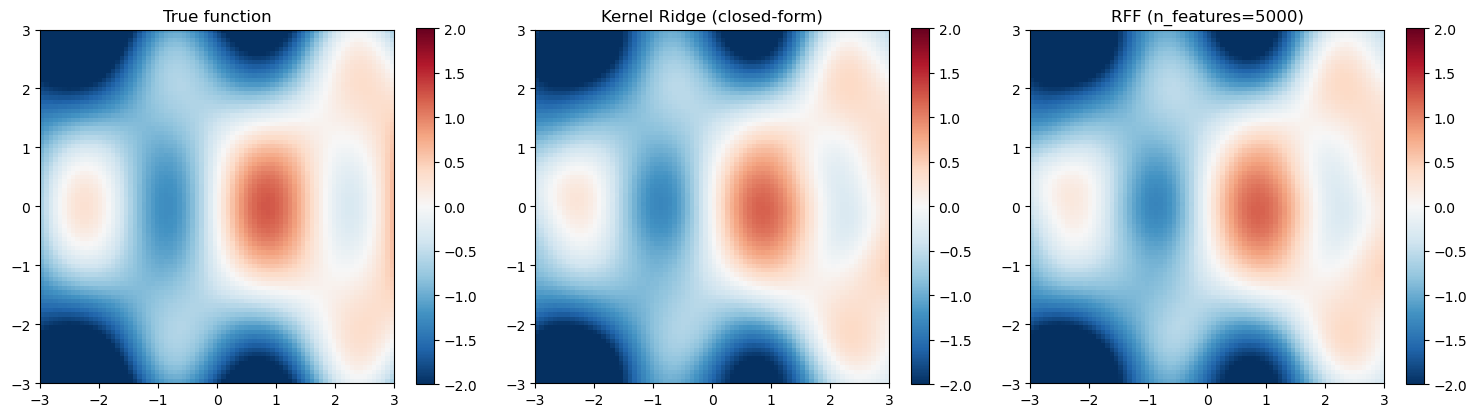

In [108]:
xs = np.linspace(-3, 3, 80)
ys = np.linspace(-3, 3, 80)
XX, YY = np.meshgrid(xs, ys)
grid = np.column_stack([XX.ravel(), YY.ravel()])

Z_true = target(grid).reshape(XX.shape)
Z_cf = model_cf.predict(grid).reshape(XX.shape)
Z_rff = model_rff.predict(grid).reshape(XX.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, Z, name in [(axes[0], Z_true, 'True function'),
                     (axes[1], Z_cf, 'Kernel Ridge (closed-form)'),
                     (axes[2], Z_rff, f'RFF (n_features={nf})')]:
    im = ax.imshow(Z, extent=[-3, 3, -3, 3], origin='lower', cmap='RdBu_r', vmin=-2, vmax=2)
    ax.set_title(name)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

>  RFF  при умеренном n_features даёт то же качество, но с линейной по числу объектов сложностью вместо $O(\ell^3)$ у closed-form.


---

## Итоги

Идея работает. RFF с логистической регрессией обучается быстрее всех рассмотренных подходов, потому что матрица Грама не строится вовсе, и по качеству не уступает линейному SVM. Точному ядровому SVM на подвыборке и градиентному бустингу она всё же проигрывает: нелинейные зависимости в Fashion MNIST улавливаются, но не полностью.

Качество монотонно растёт с числом случайных признаков и выходит на плато около 1000. Это согласуется с теорией — дисперсия аппроксимации ядра убывает как $O(1/n)$, дальше увеличивать размерность бессмысленно. Линейный SVM поверх RFF стабильно чуть лучше логистической регрессии, и разрыв заметнее как раз после выхода на плато, когда ядро уже аппроксимировано хорошо.

PCA перед генерацией признаков ускоряет всё существенно и почти не стоит качества. Ортогонализация (ORF) уменьшает дисперсию оценки, не меняя матожидания, и заметнее всего помогает при малом числе признаков. FastFood при сопоставимом качестве меняет асимптотику генерации с $O(nd)$ на $O(n\log d)$, хотя на сжатом PCA-пространстве выигрыш во времени незаметен — он проявится на больших размерностях.

В регрессионной части аналитическое решение оказалось точнее градиентного спуска (MSE 0.0186 против 0.0199): спектр матрицы Грама сильно растянут, и GD сходится медленно. RFF при умеренном числе признаков достигает того же качества с линейной сложностью по числу объектов вместо $O(\ell^3)$.
